In [1]:
import pandas as pd
from plotnine import *
import matplotlib.pyplot as plt

start = 35
end = 61

# Read the CSV file
df = pd.read_csv(f'orderfilled_events/orderfilled_{start}-{end}_no_ctfexchange.csv')

# Convert 'blockNumber' and 'txIndex' to integers if necessary
df['blockNumber'] = df['blockNumber'].astype(int)
df['txIndex'] = df['txIndex'].astype(int)

# Calculate 'usdc_amount' based on 'makerAssetId' and 'takerAssetId'
def calculate_usdc_amount(row):
    usdc_amount = 0
    if row['makerAssetId'] == '0':
        usdc_amount += row['makerAmountFilled']/1000000
    if row['takerAssetId'] == '0':
        usdc_amount += row['takerAmountFilled']/1000000
    return usdc_amount

df['usdc_amount'] = df.apply(calculate_usdc_amount, axis=1)

# Filter out rows where 'usdc_amount' is zero
df_trades = df[df['usdc_amount'] > 0].copy()



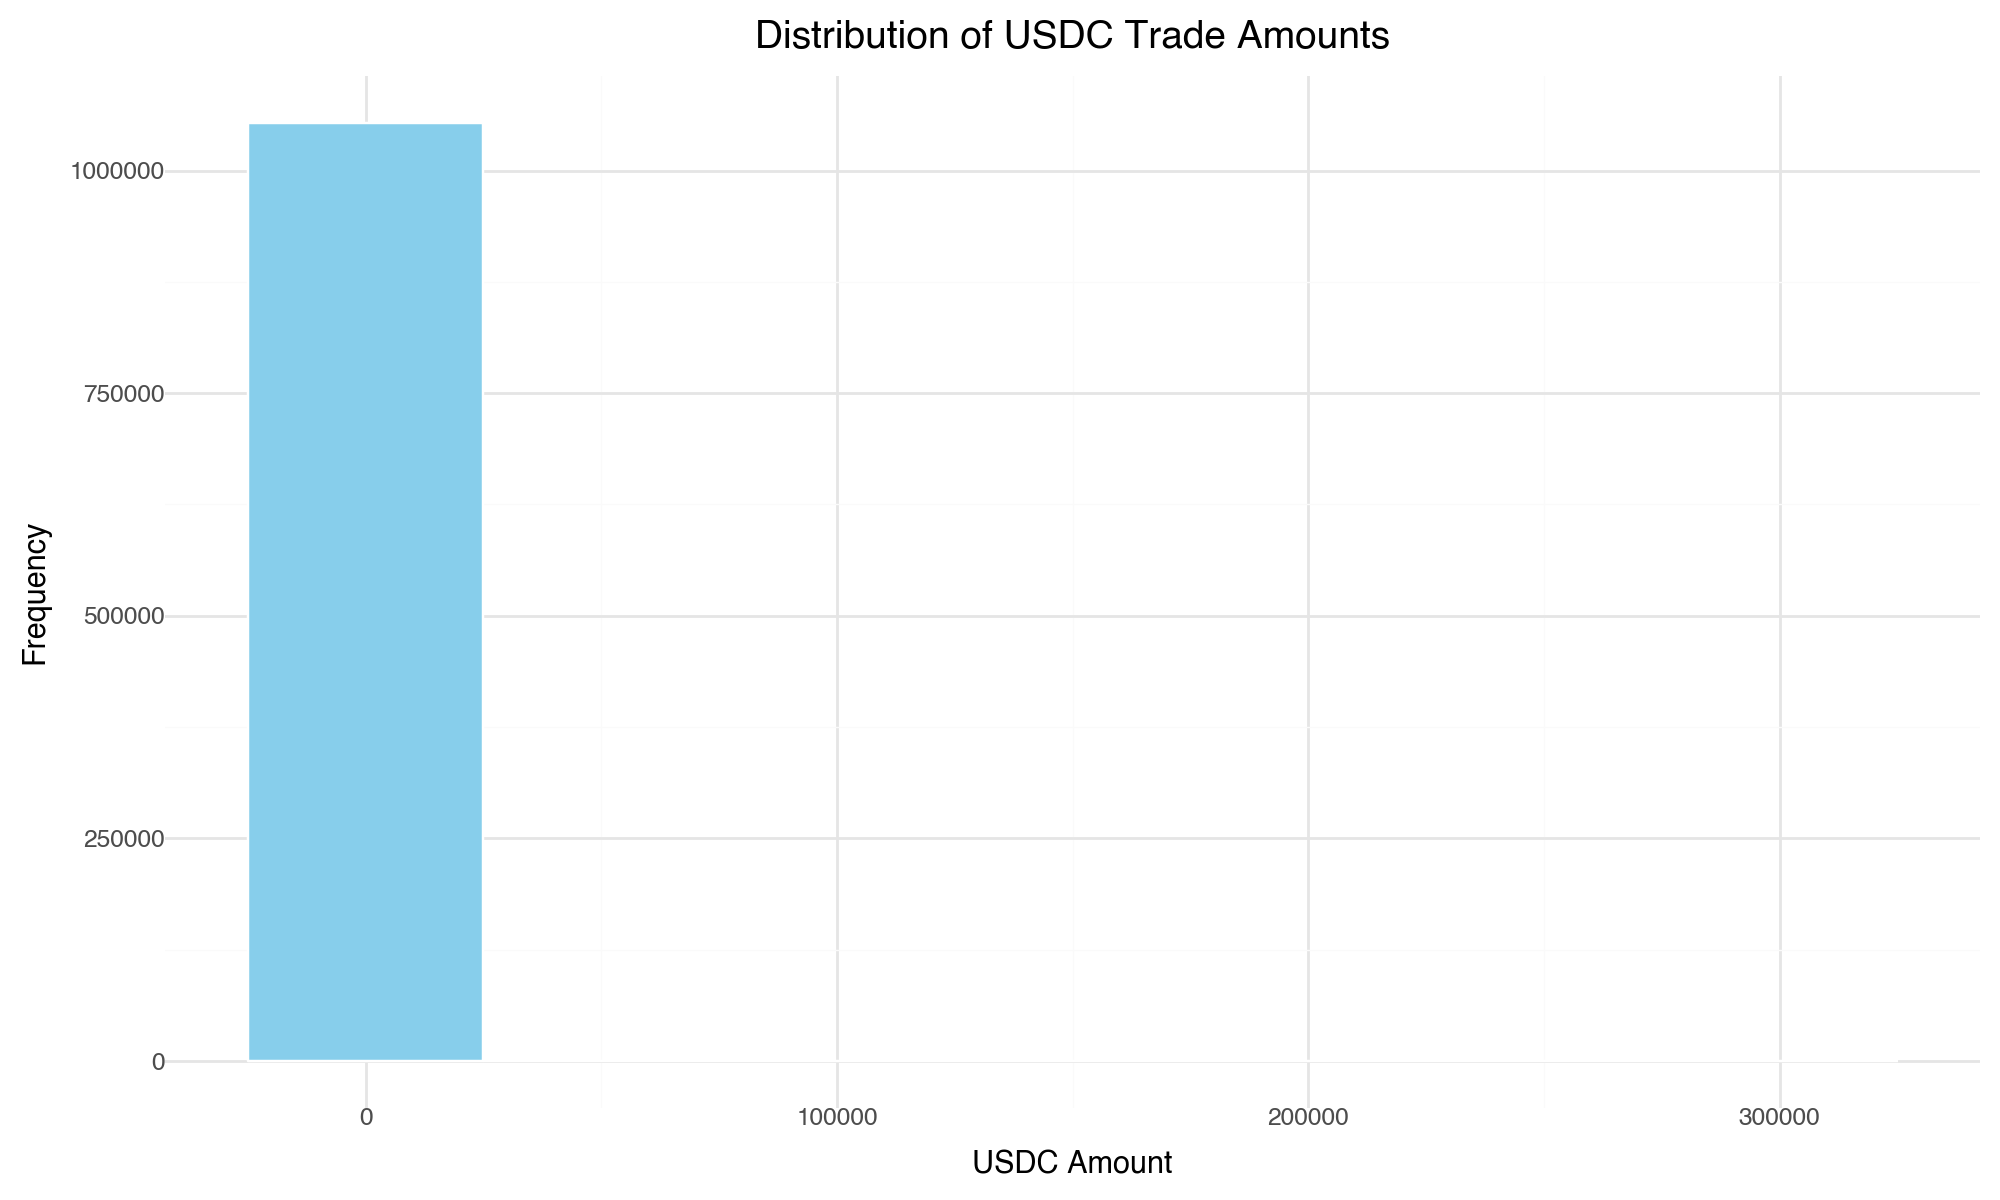

In [2]:

#df_trades = df_trades[df_trades['usdc_amount'] > 10000].copy()

(
    ggplot(df_trades, aes(x='usdc_amount')) +
    geom_histogram(binwidth=50000, fill='skyblue', color='white') +
    theme_minimal() +
    labs(title='Distribution of USDC Trade Amounts', x='USDC Amount', y='Frequency') +
    theme(
        plot_title=element_text(size=14, weight='bold'),
        figure_size=(10, 6)
    )
)



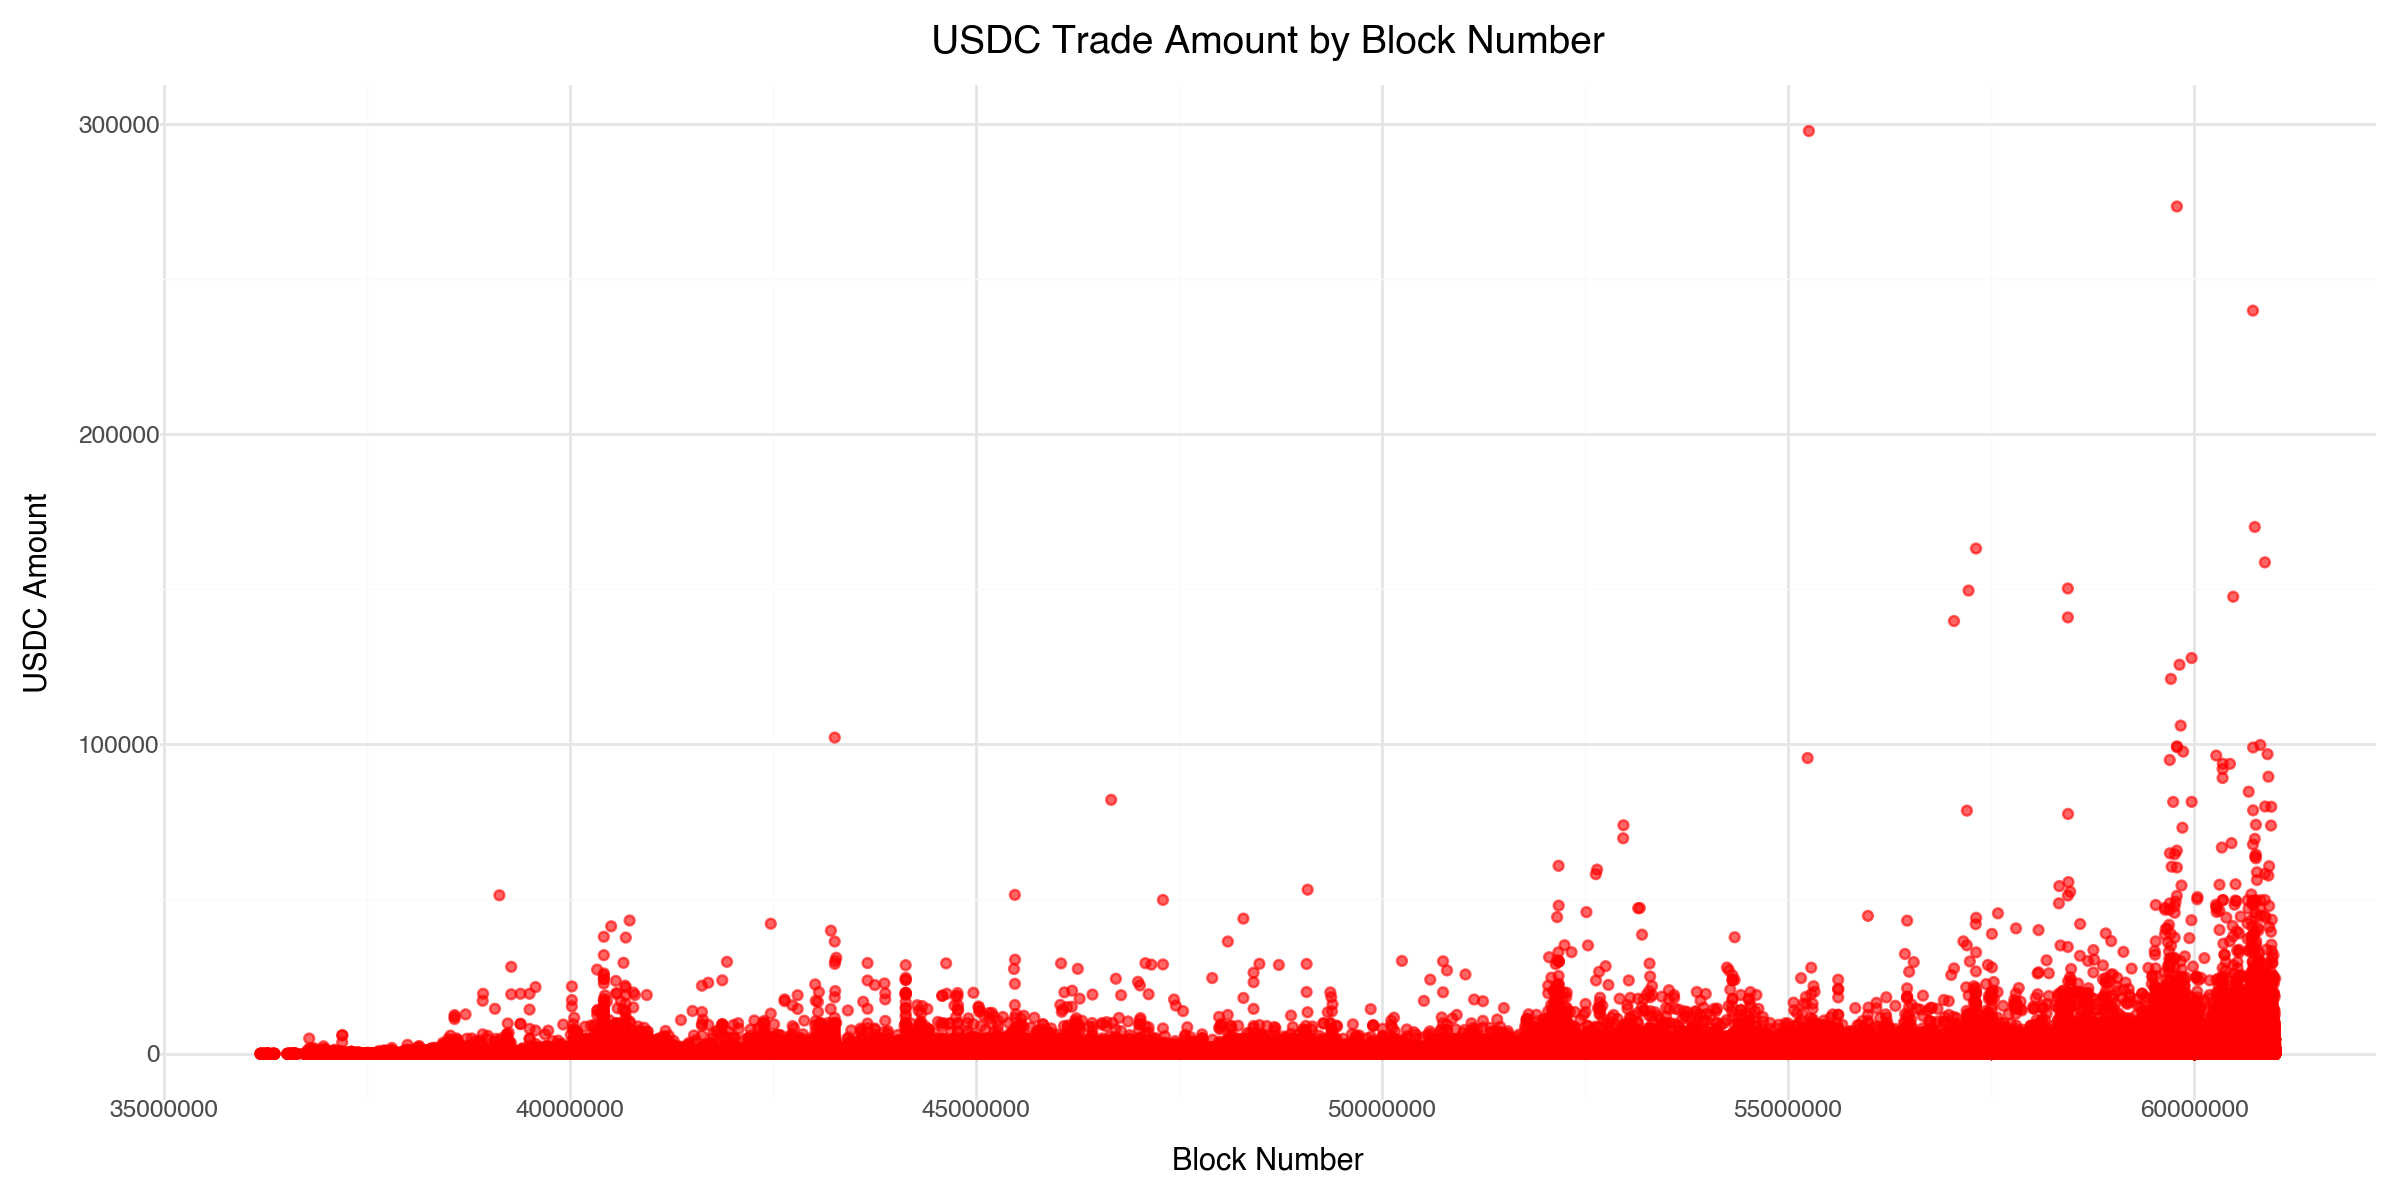

In [3]:
(
    ggplot(df_trades, aes(x='blockNumber', y='usdc_amount')) +
    geom_point(alpha=0.6, color='red') +
    theme_minimal() +
    labs(title='USDC Trade Amount by Block Number', x='Block Number', y='USDC Amount') +
    theme(
        plot_title=element_text(size=14, weight='bold'),
        figure_size=(12, 6)
    )
)



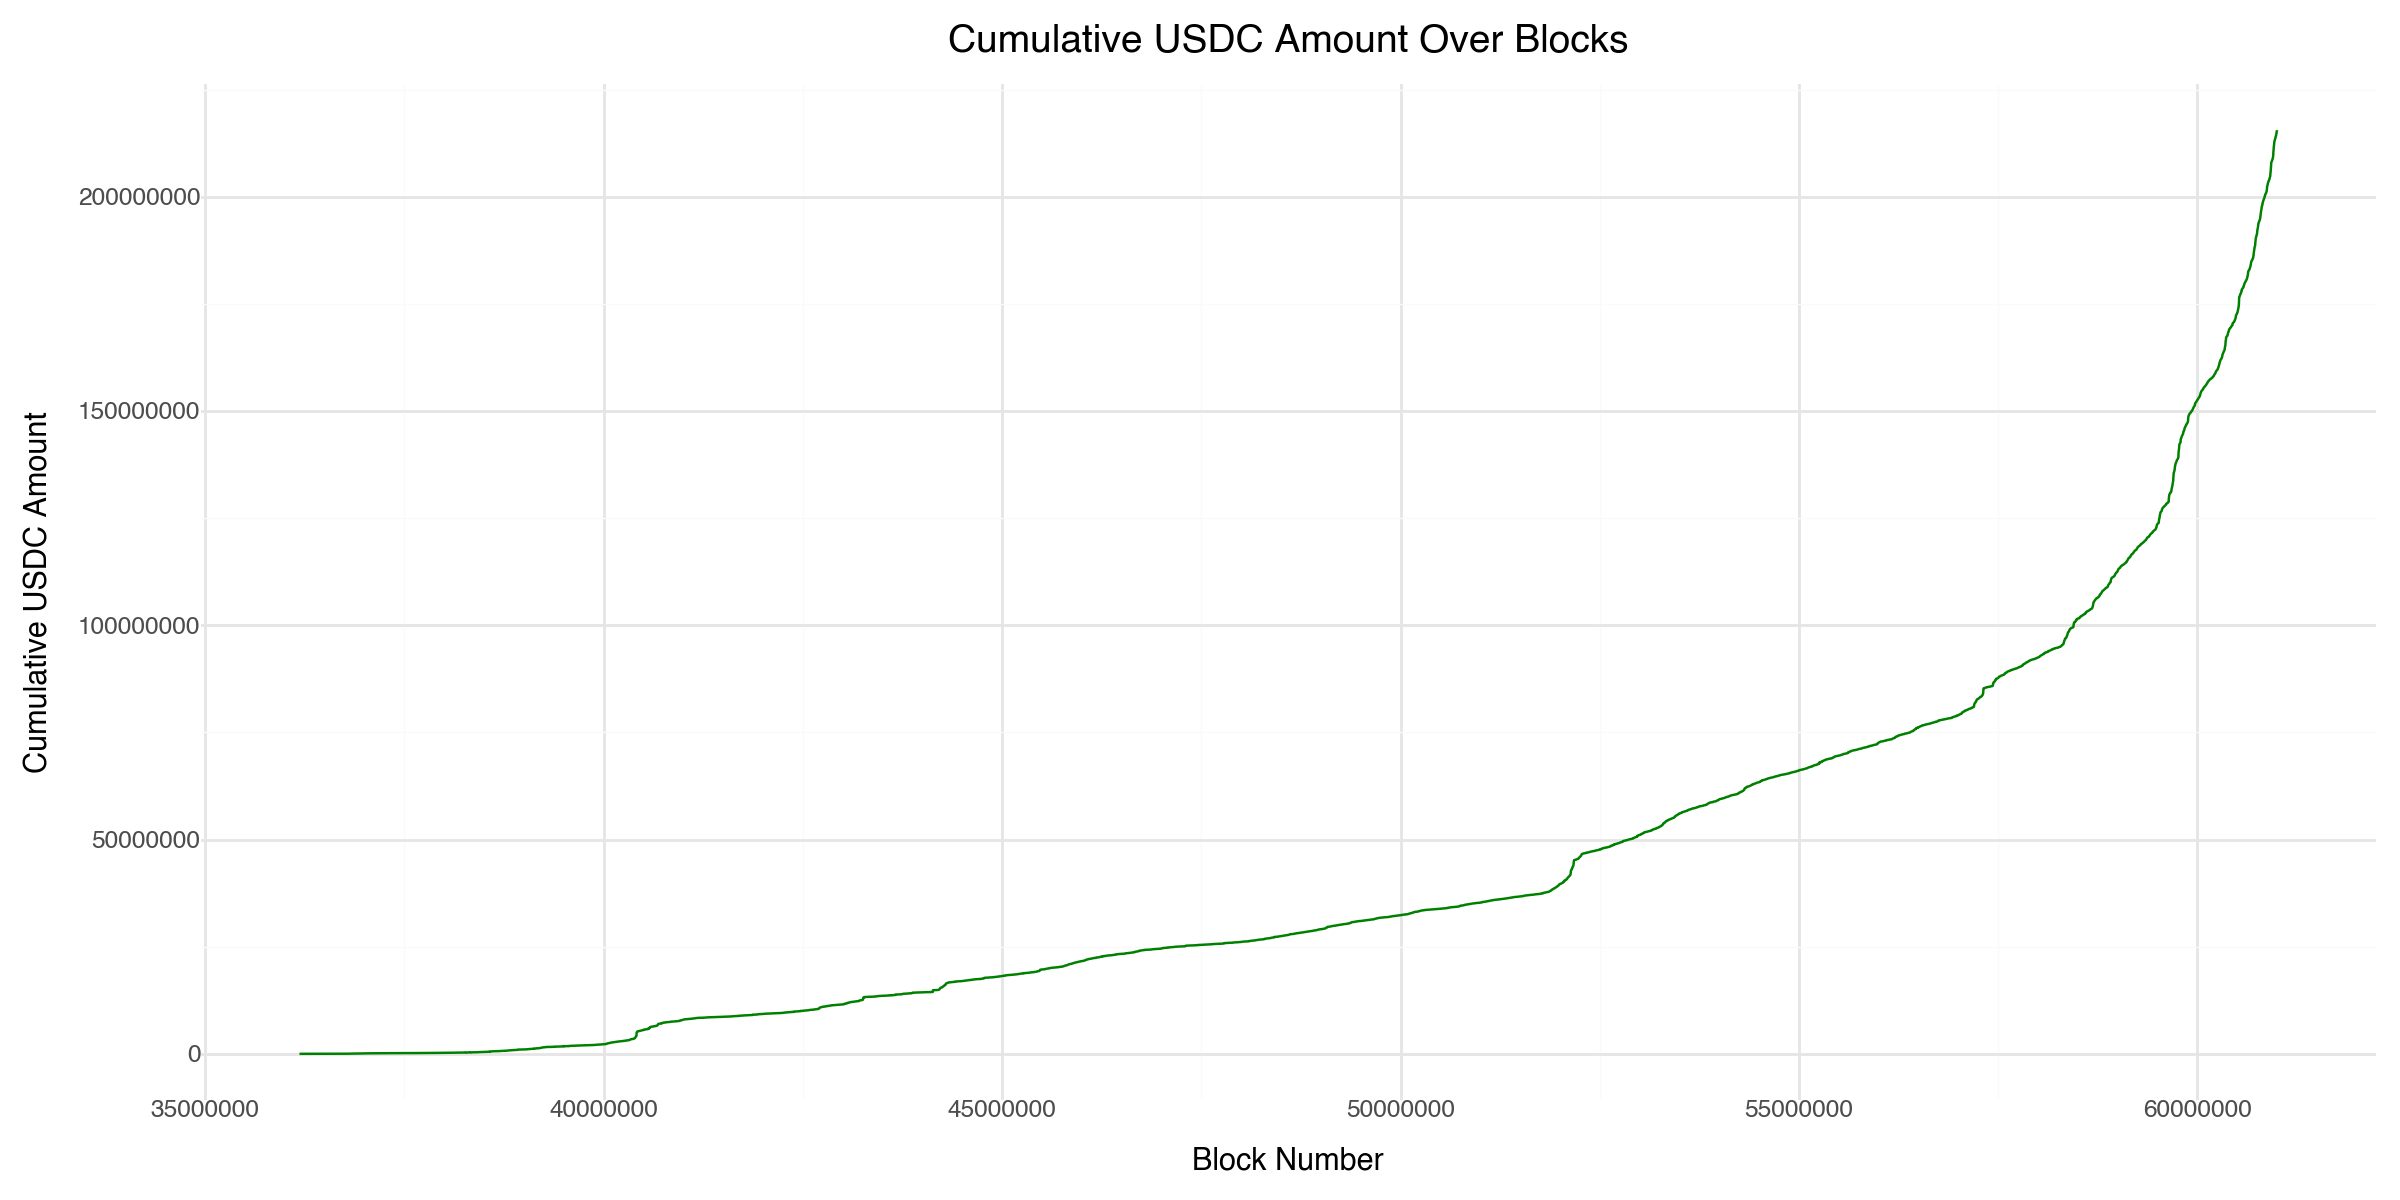

In [4]:
# Calculate cumulative USDC amount
df_trades_sorted = df_trades.sort_values('blockNumber')
df_trades_sorted['cumulative_usdc'] = df_trades_sorted['usdc_amount'].cumsum()

(
    ggplot(df_trades_sorted, aes(x='blockNumber', y='cumulative_usdc')) +
    geom_line(color='green') +
    theme_minimal() +
    labs(title='Cumulative USDC Amount Over Blocks', x='Block Number', y='Cumulative USDC Amount') +
    theme(
        plot_title=element_text(size=14, weight='bold'),
        figure_size=(12, 6)
    )
)




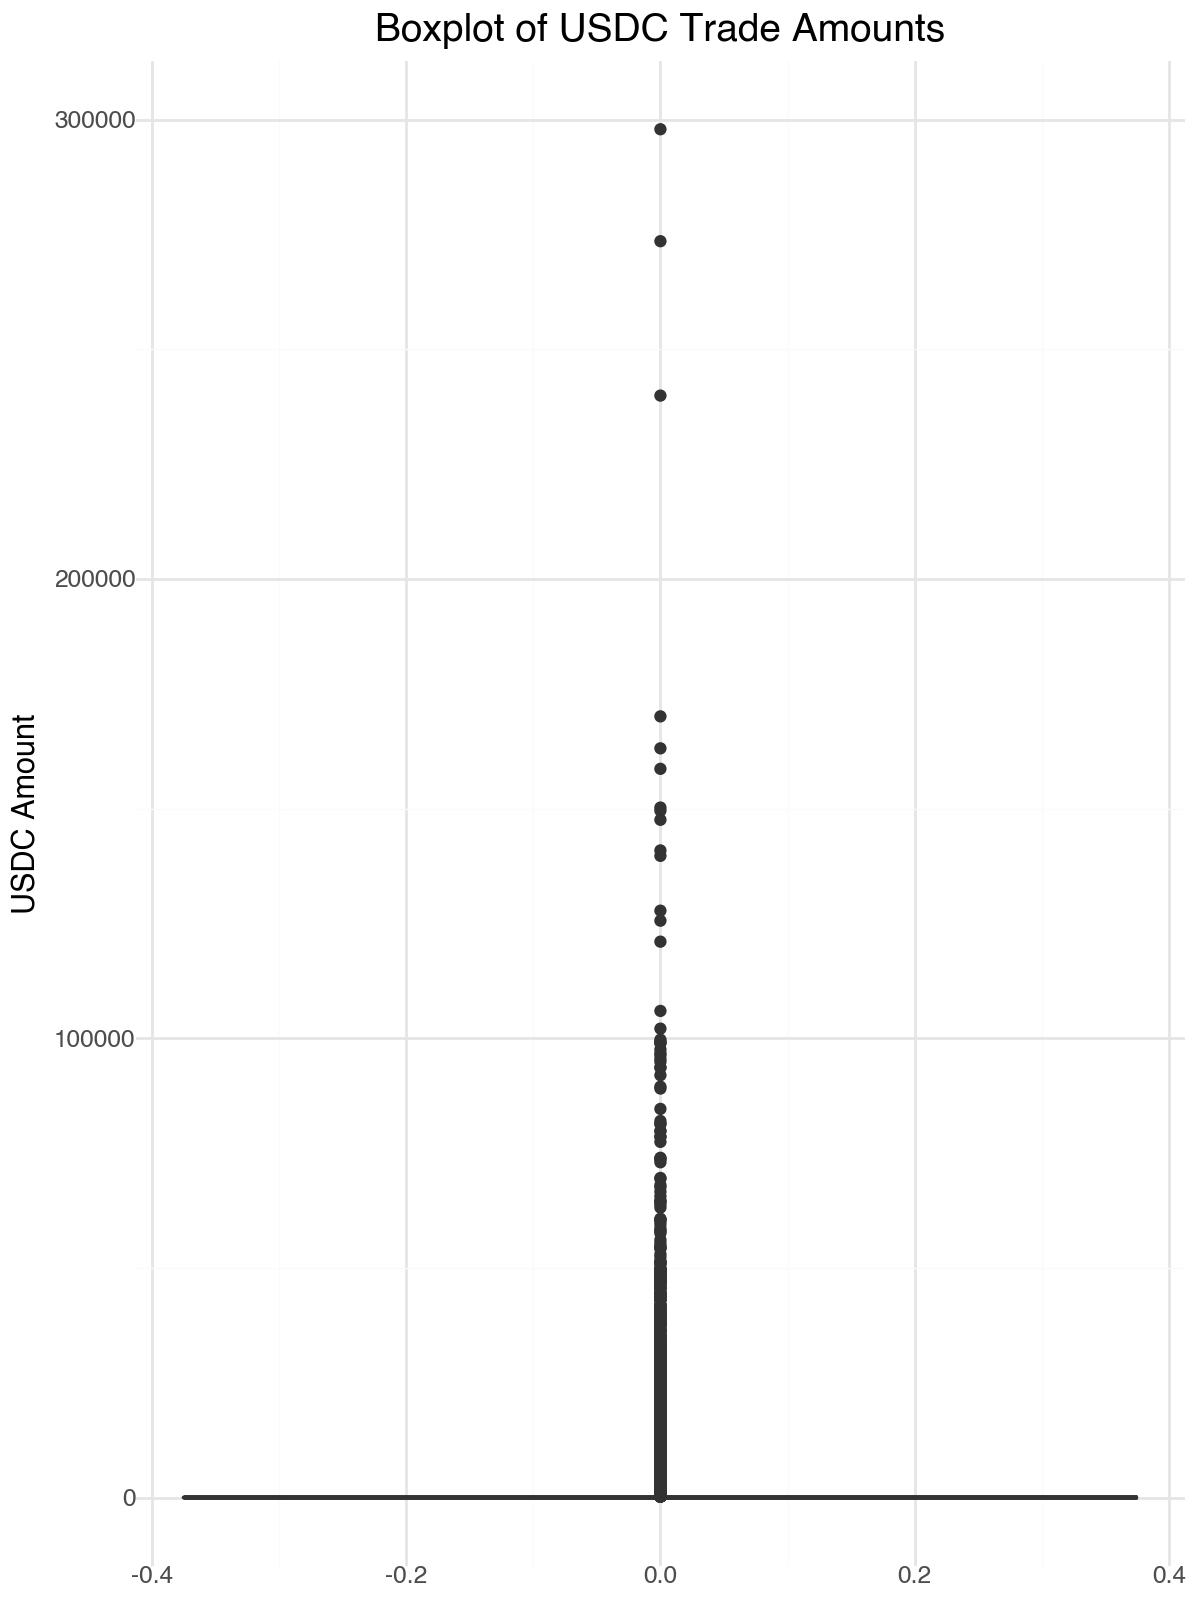

In [6]:
(
    ggplot(df_trades, aes(y='usdc_amount')) +
    geom_boxplot(fill='orange', alpha=0.7) +
    theme_minimal() +
    labs(title='Boxplot of USDC Trade Amounts', y='USDC Amount') +
    theme(
        plot_title=element_text(size=14, weight='bold'),
        figure_size=(6, 8)
    )
)


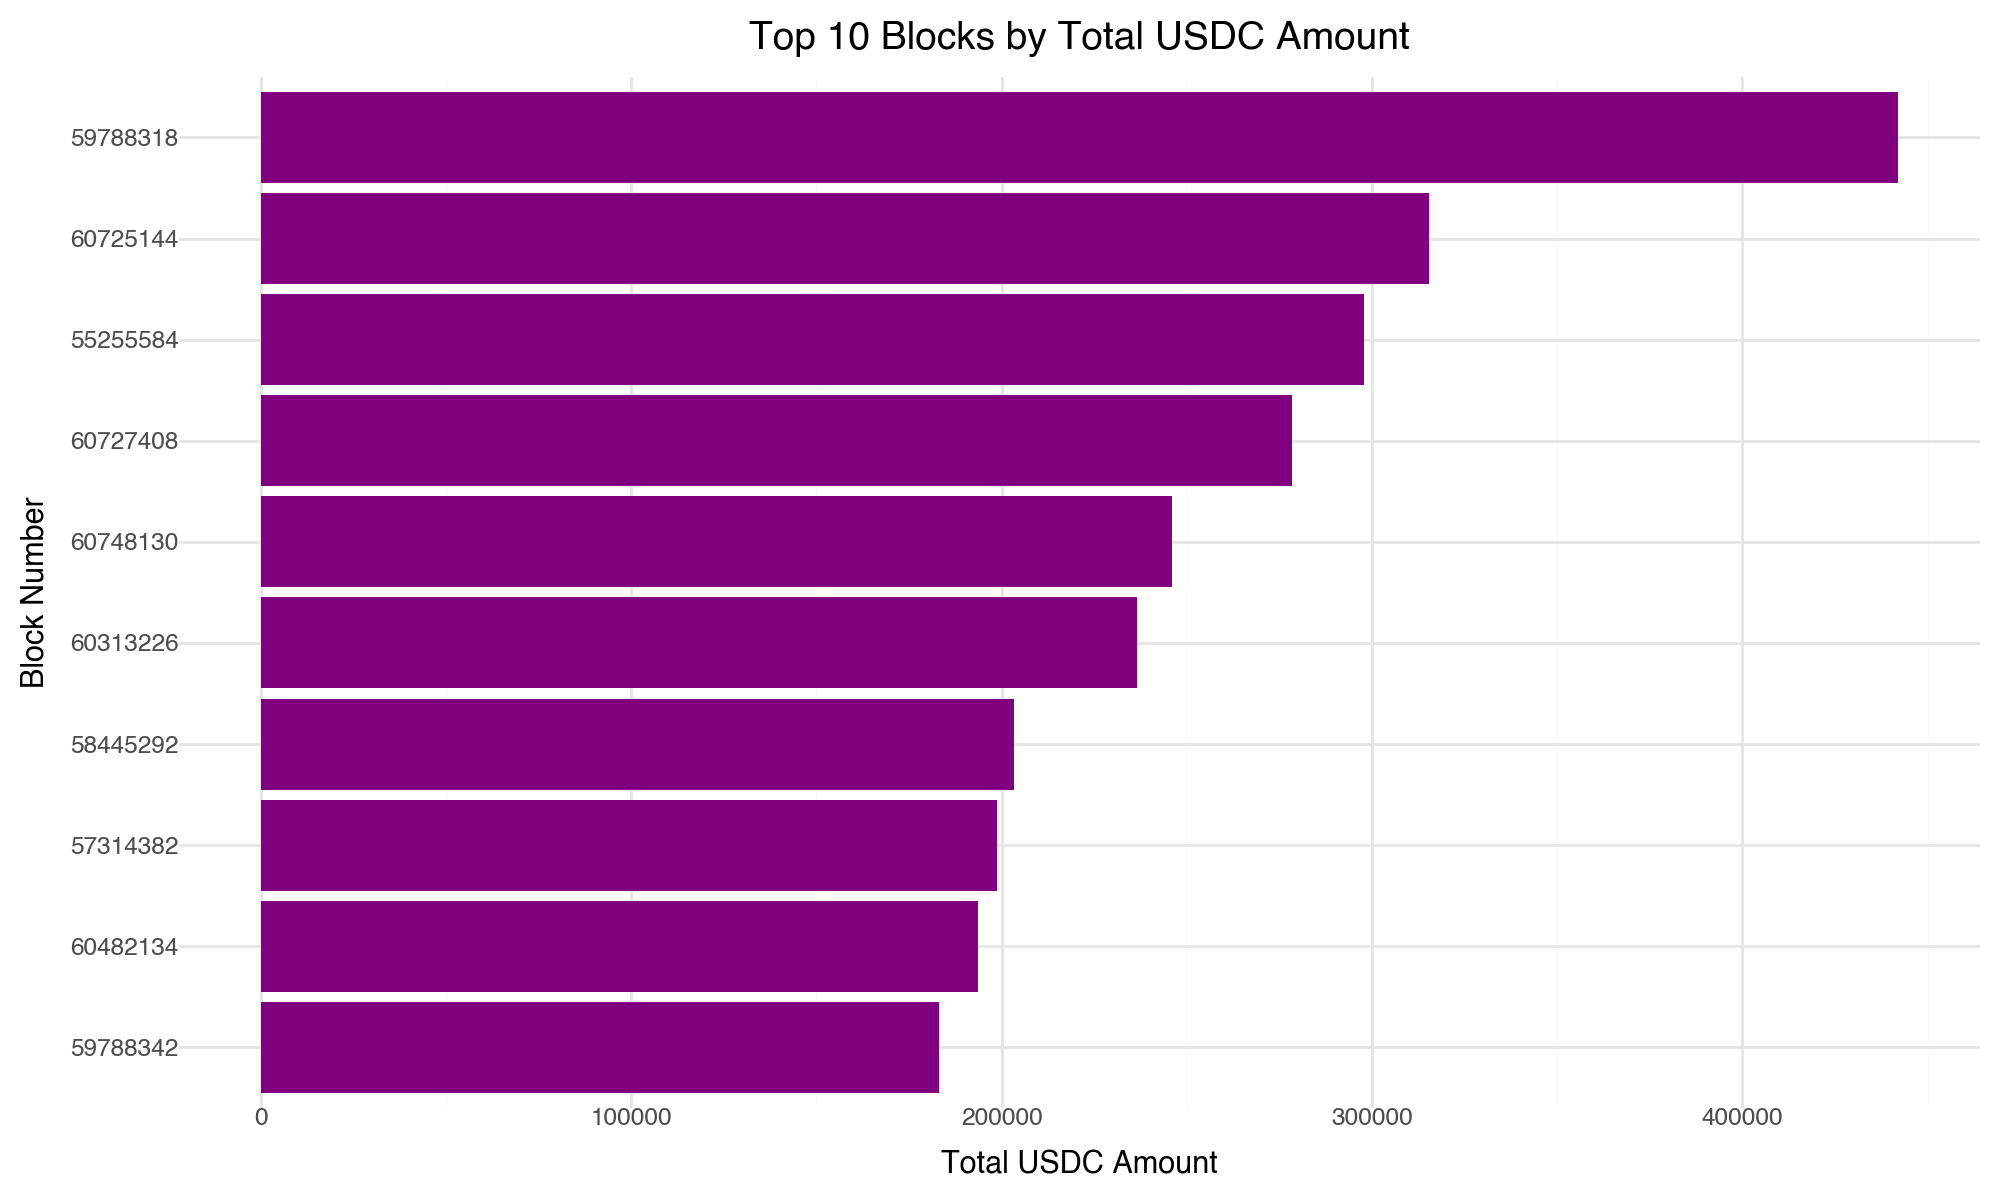

In [8]:
df_trades_grouped = df_trades.groupby('blockNumber')['usdc_amount'].sum().reset_index()
df_top_blocks = df_trades_grouped.sort_values('usdc_amount', ascending=False).head(10)

(
    ggplot(df_top_blocks, aes(x='reorder(factor(blockNumber), usdc_amount)', y='usdc_amount')) +
    geom_bar(stat='identity', fill='purple') +
    coord_flip() +  # Flip coordinates for better readability
    theme_minimal() +
    labs(title='Top 10 Blocks by Total USDC Amount', x='Block Number', y='Total USDC Amount') +
    theme(
        plot_title=element_text(size=14, weight='bold'),
        figure_size=(10, 6)
    )
)